# Result Plots

In [6]:
from utils.utils import *
import os
import json
import matplotlib.pyplot as plt
import math

In [7]:
bool_150 = False
bool_150test = False
bool_balanced_test = True
bool_inverted = False
PATH_SUFFIX = create_path_suffix(
    bool_150=bool_150,
    bool_150test=bool_150test,
    bool_balanced_test=bool_balanced_test,
    bool_inverted=bool_inverted
)

TOPIC_ORDER = ['politics', 'general', 'covid', 'syria', 'islam', 'notredame', 'gossip'] # Topic order for plots
if bool_inverted:
    TOPIC_ORDER = TOPIC_ORDER[::-1]
DATE_ORDER = ['2011-2015', '2016', '2017', '2019', '2020'] # Date order for plots
MODEL_ORDER = ['Linear', 'NB', 'PA', 'CNN', 'BiLSTM', 'BERT', 'DeBERTa', 'RoBERTa'] # Model order for plots

#### Plot Functions

In [8]:
def load_data(type='topic'):
    """
    Scan the RESULTS_DIR for model folders and load their JSON results, considering only the specified type.

    Args:
        type (str): Type of results to load ('topic' or 'date').
    
    Returns:
        dict: A dictionary with model names as keys and their loaded JSON data as values.
    """

    model_data = {}

    for folder_name in os.listdir("results"):
        folder_path = os.path.join("results", folder_name)
        
        # Considering only folders ending with the specified type
        if os.path.isdir(folder_path) and folder_name.endswith(f'_{type}'):
            parts = folder_name.split('_')
            
            # Get MODEL name from folder "results_{MODEL}_{type}"
            model_name = parts[1] 
            
            # JSON paths for Full Topic and Single Topic results
            full_path = os.path.join(folder_path, f'results_full_{type}{PATH_SUFFIX}.json')
            single_path = os.path.join(folder_path, f'results_single_{type}{PATH_SUFFIX}.json')
            
            data = {'full': None, 'single': None}
            
            # Load data from Full Topic
            if os.path.exists(full_path):
                with open(full_path, 'r') as f:
                    data['full'] = json.load(f)
            
            # Load data from Single Topic
            if os.path.exists(single_path):
                with open(single_path, 'r') as f:
                    data['single'] = json.load(f)
            
            if data['full'] or data['single']:
                model_data[model_name] = data
            
            # Order models data according to MODEL_ORDER
            ordered_model_data = {k: model_data[k] for k in MODEL_ORDER if k in model_data}

    return ordered_model_data


def load_random_baseline(type='topic'):
    """
    Load random baseline results (mean and std) for the given type.

    Args:
        type (str): Type of results to load ('topic' or 'date').

    Returns:
        tuple: A tuple containing mean and std of the random baseline.
    """

    path = f"results/results_random_{type}/random_baseline_full_test.json"
    
    if not os.path.exists(path):
        print(f"[WARNING] Random baseline file not found: {path}")
        return None
    
    with open(path, "r") as f:
        data = json.load(f)
    
    return data["mean"], data["std"]


def plot_full_comparison(model_data, type_order, type='topic'):
    """
    Plot of F1-score on Full Test Set across all models.

    Args:
        model_data (dict): Dictionary containing model results loaded from JSON files.
        type_order (list): List of topics/dates to iterate through.
        type (str): Label for the x-axis ('topic' or 'date').
    """

    plt.figure(figsize=(10, 5))

    # --- Plot models ---
    for model_name, data in model_data.items():
        if data['full']:
            x_values = []
            y_values = []
            for task in type_order: # Extract values ordered according to topic/data order
                if task in data['full']:
                    x_values.append(task)
                    y_values.append(data['full'][task])

            plt.plot(x_values, y_values, marker='o', linewidth=2, label=model_name)

    # --- Plot random baseline ---
    random_data = load_random_baseline(type)

    if random_data is not None:
        random_mean, random_std = random_data
        n_tasks = len(type_order)

        x_vals = type_order
        y_mean = [random_mean] * n_tasks
        y_low = [random_mean - random_std] * n_tasks
        y_high = [random_mean + random_std] * n_tasks

        # mean line
        plt.plot(x_vals, y_mean, linestyle='--', color='black', linewidth=2, label='Random baseline')
        # std band
        plt.fill_between(x_vals, y_low, y_high, color='gray', alpha=0.2, label='Random ± std')

    # --- Plot settings ---
    plt.title('Model Comparison: F1-score on Full Test Set')
    plt.xlabel(f'Fine-tuning {type.capitalize()}')
    plt.ylabel('Weighted F1-score')
    plt.legend(title='Models', loc='best')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_cumulative_comparison(model_data, type_order, type='topic'):
    """
    Plot of F1-score on Cumulative Test Set across all models.

    Args:
        model_data (dict): Dictionary containing model results loaded from JSON files.
        type_order (list): List of topics/dates to iterate through.
        type (str): Label for the x-axis ('topic' or 'date').
    """

    plt.figure(figsize=(10, 5))

    # --- Plot models ---
    for model_name, data in model_data.items():
        if data['cumulative']:
            x_values = []
            y_values = []
            for task in type_order: # Extract values ordered according to topic/data order
                if task in data['cumulative']:
                    x_values.append(task)
                    y_values.append(data['cumulative'][task])

            plt.plot(x_values, y_values, marker='o', linewidth=2, label=model_name)

    # --- Plot random baseline ---
    random_data = load_random_baseline(type)

    if random_data is not None:
        random_mean, random_std = random_data
        n_tasks = len(type_order)

        x_vals = type_order
        y_mean = [random_mean] * n_tasks
        y_low = [random_mean - random_std] * n_tasks
        y_high = [random_mean + random_std] * n_tasks

        # mean line
        plt.plot(x_vals, y_mean, linestyle='--', color='black', linewidth=2, label='Random baseline')
        # std band
        plt.fill_between(x_vals, y_low, y_high, color='gray', alpha=0.2, label='Random ± std')

    # --- Plot settings ---
    plt.title('Model Comparison: F1-score on Cumulative Test Set')
    plt.xlabel(f'Fine-tuning {type.capitalize()}')
    plt.ylabel('Weighted F1-score')
    plt.legend(title='Models', loc='best')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_single_comparisons(model_data, type_order, type='topic'):
    """
    Plot of F1-score on Single Topic Test Sets across all models arranged in a 2-column grid.

    Args:
        model_data (dict): Dictionary containing model results loaded from JSON files.
        type_order (list): List of topics/dates to iterate through.
        type (str): Label for the x-axis ('topic' or 'date').
    """
    
    # Number of columns and rows needed for subplots
    num_plots = len(type_order)
    num_cols = 2
    num_rows = math.ceil(num_plots / num_cols)
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
    axes = axes.flatten()

    # Iterate over each topic/date and the corresponding axis
    for i, target_test_type in enumerate(type_order):
        ax = axes[i] # Select the subplot axis
        has_data = False
        
        for model_name, data in model_data.items():
            if data['single']:
                y_values = []
                x_values = []
                
                # Get scores for the target_test_type across all fine-tuning topics/dates
                for ft_type in type_order:
                    # JSON structure: {FT_Type: {Test_Type: score, ...}}
                    if ft_type in data['single']:
                        scores_dict = data['single'][ft_type]
                        if target_test_type in scores_dict:
                            x_values.append(ft_type)
                            y_values.append(scores_dict[target_test_type])
                if y_values:
                    ax.plot(x_values, y_values, marker='o', label=model_name)
                    has_data = True
        
        # Graphic settings for the single subplot
        if has_data:
            ax.set_title(f'Test Set: "{target_test_type.upper()}"')
            ax.set_xlabel(f'Fine-tuning {type.capitalize()}')
            ax.set_ylabel('F1-score')
            ax.grid(True, linestyle='--', alpha=0.7)
            ax.legend(fontsize='small', title='Models') # Smaller legend font size
        else:
            ax.text(0.5, 0.5, 'No Data', horizontalalignment='center', verticalalignment='center')

    # Remove empty axes (if the number of plots is odd)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

## Results: Topic

Found data for models: ['Linear', 'NB', 'PA', 'CNN', 'BiLSTM', 'BERT', 'DeBERTa', 'RoBERTa']

GENERATING PLOT FOR FULL TEST SET COMPARISON...


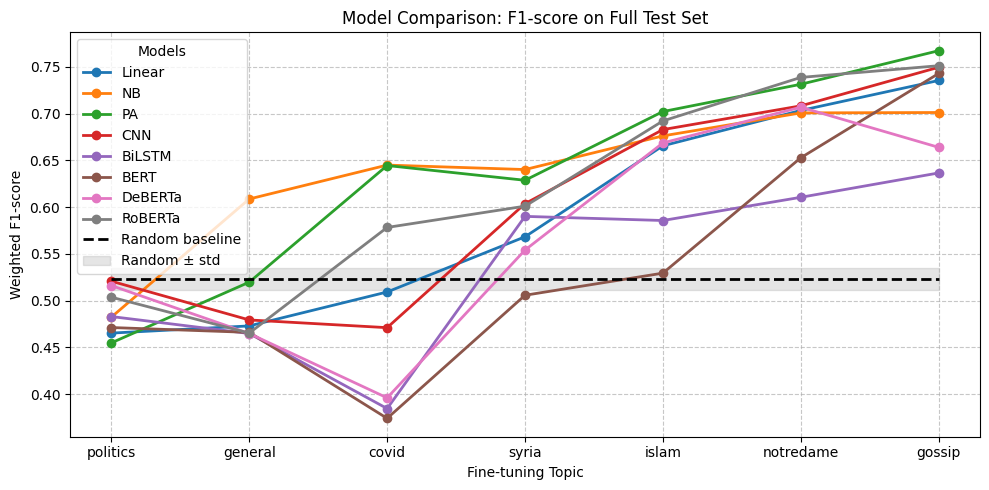


GENERATING PLOT FOR SINGLE TOPIC COMPARISONS...


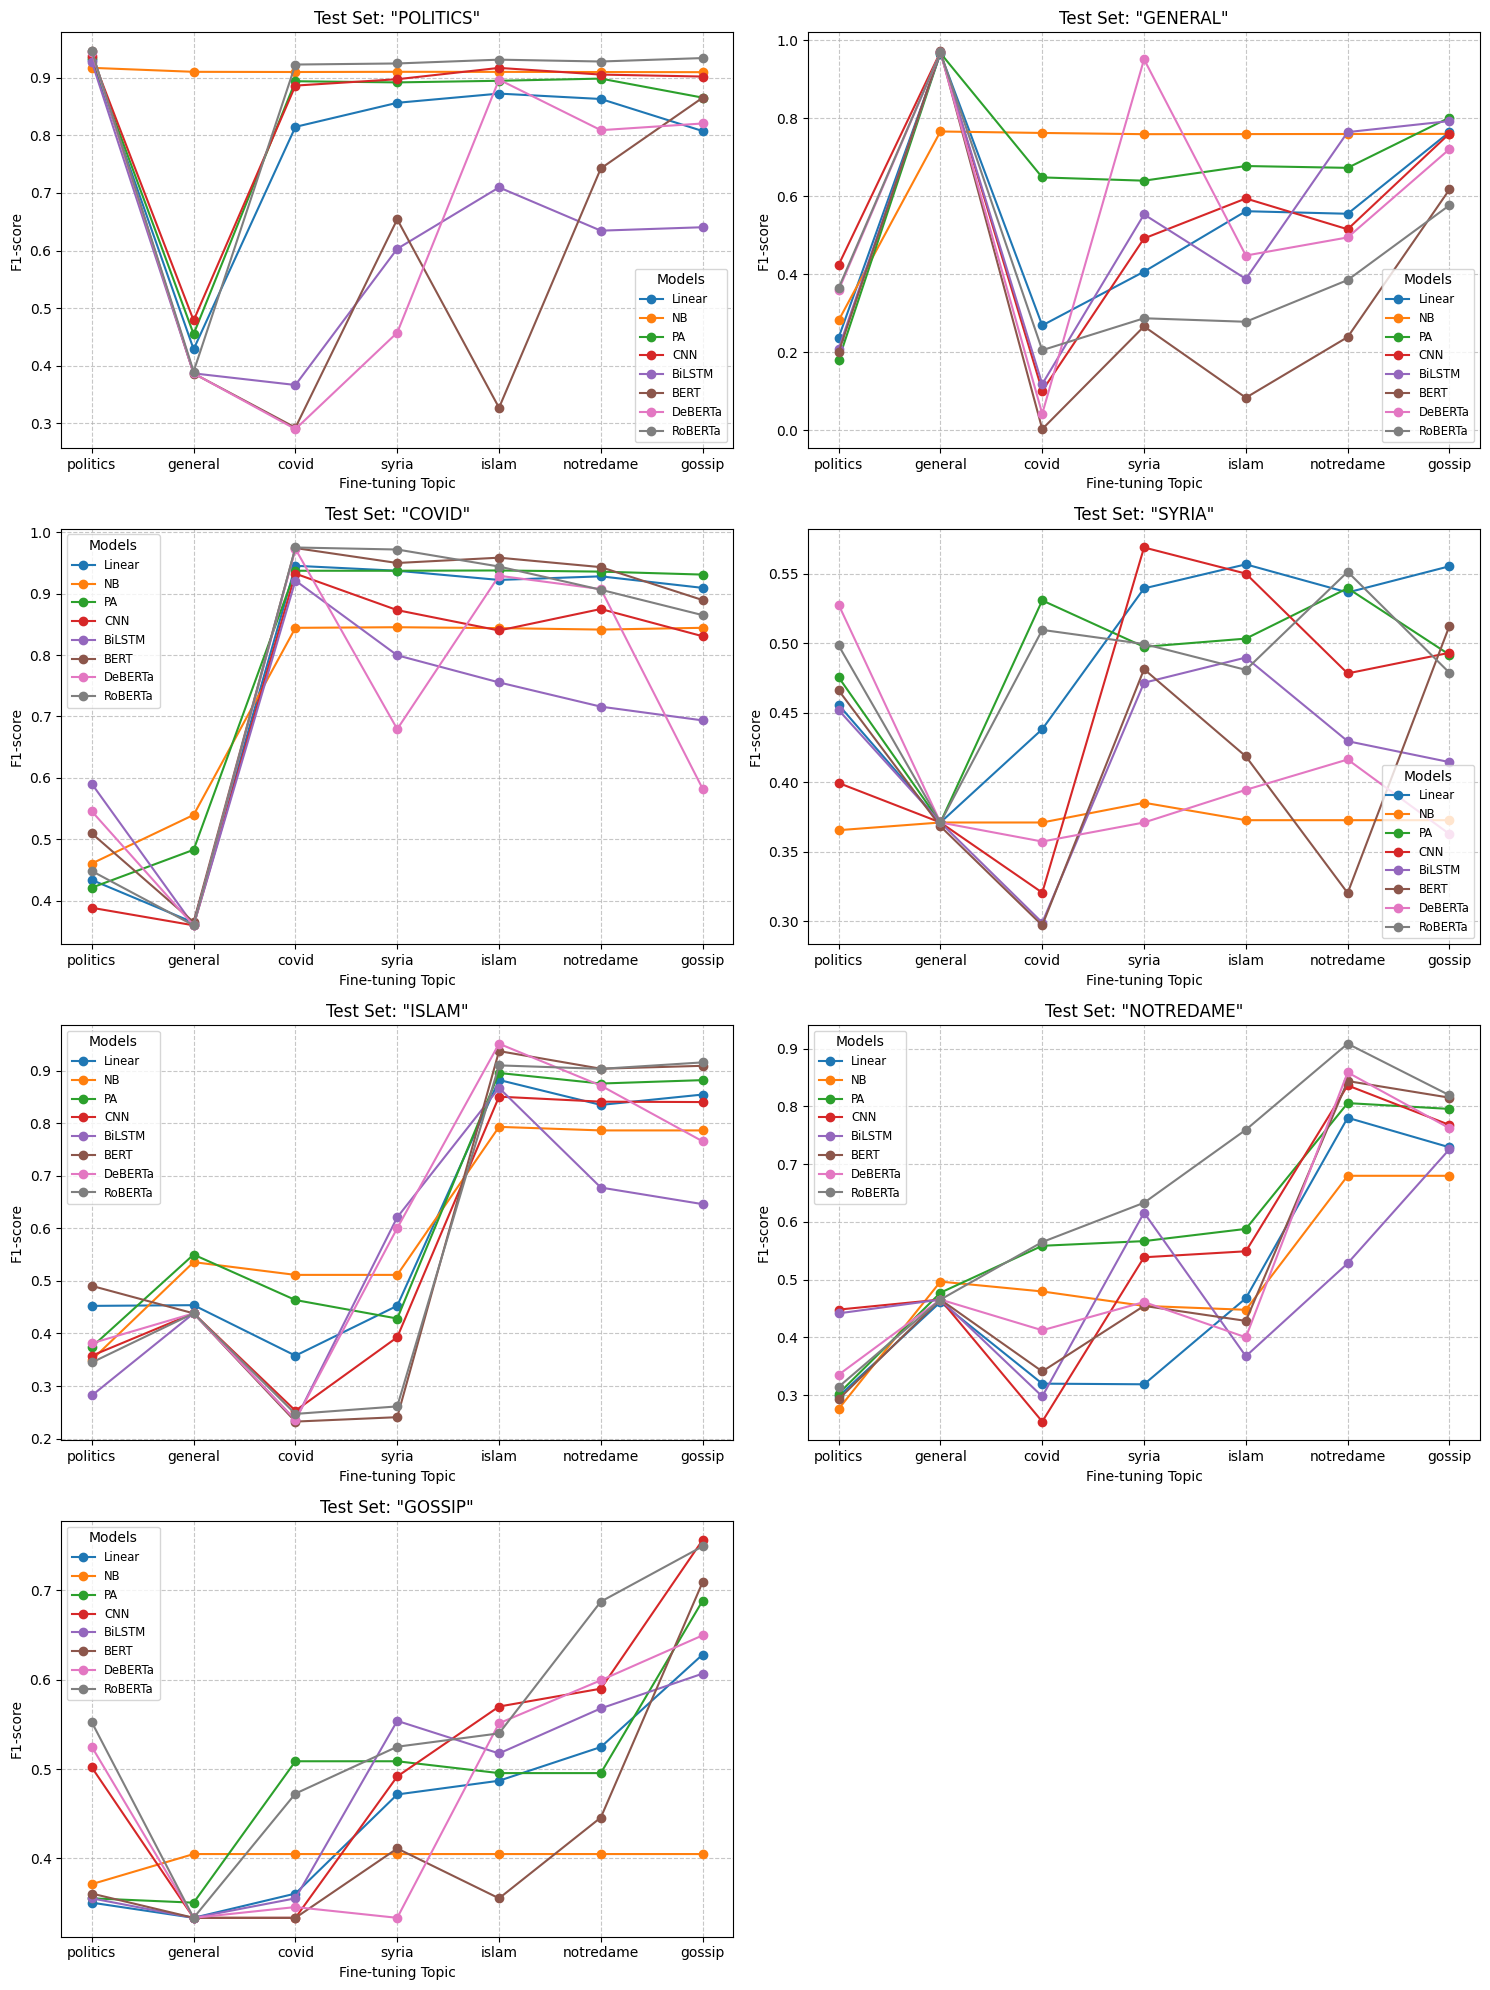

In [9]:
data = load_data(type="topic")

print(f"Found data for models: {list(data.keys())}")

print("\nGENERATING PLOT FOR FULL TEST SET COMPARISON...")
plot_full_comparison(data, type_order=TOPIC_ORDER, type="topic")

print(f"\nGENERATING PLOT FOR SINGLE TOPIC COMPARISONS...")
plot_single_comparisons(data, type_order=TOPIC_ORDER, type="topic")

## Results: Date

Found data for models: ['Linear', 'NB', 'PA', 'CNN', 'BiLSTM', 'BERT', 'DeBERTa', 'RoBERTa']

GENERATING PLOT FOR FULL TEST SET COMPARISON...


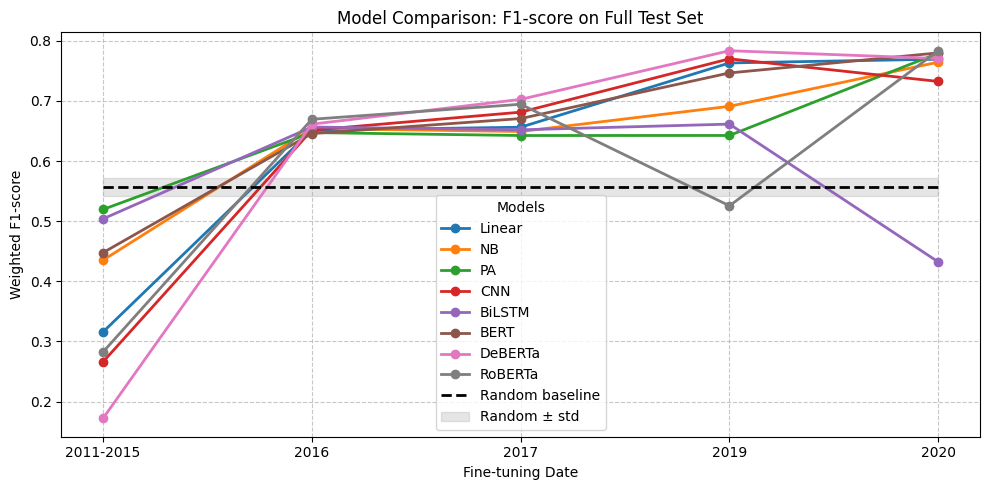


GENERATING PLOT FOR SINGLE DATE COMPARISONS...


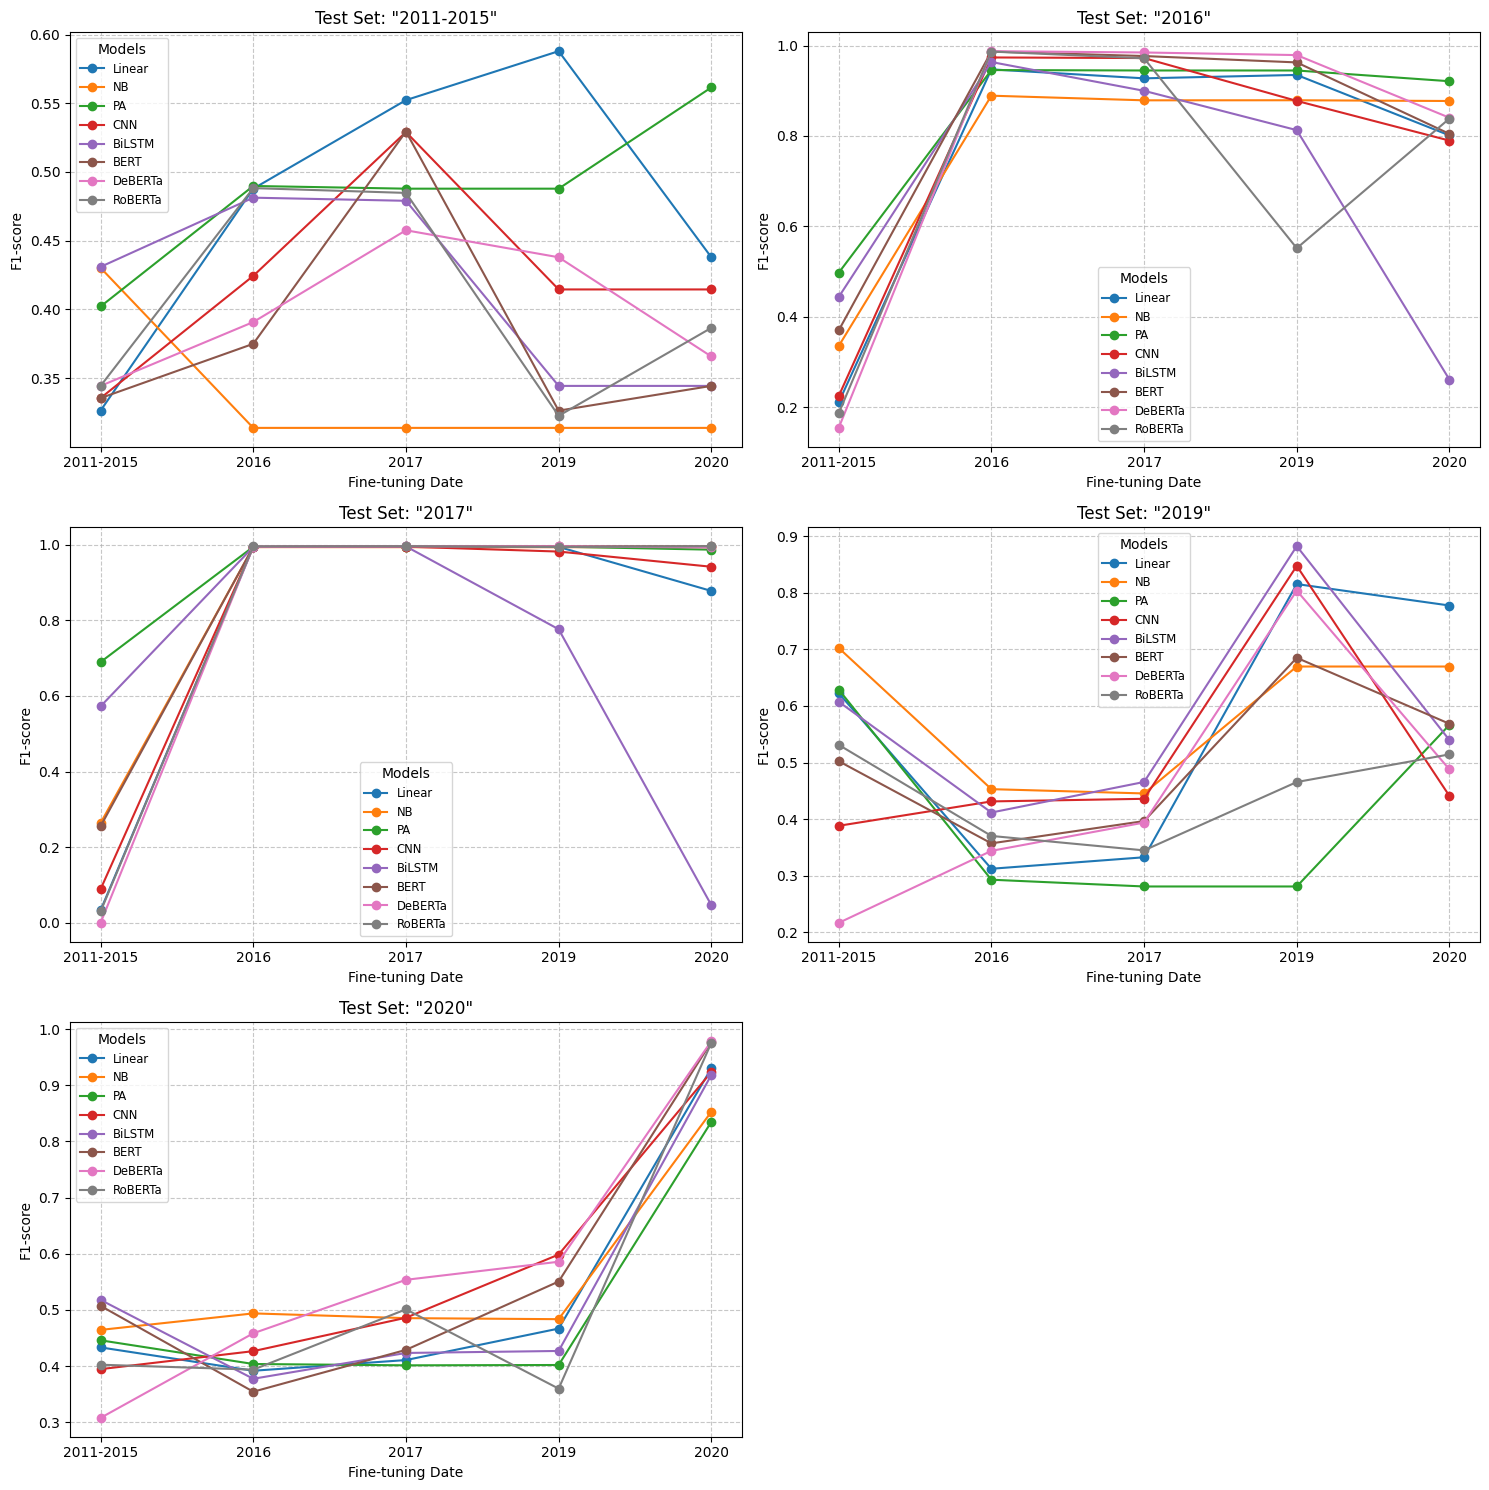

In [10]:
data = load_data(type='date')

print(f"Found data for models: {list(data.keys())}")

print("\nGENERATING PLOT FOR FULL TEST SET COMPARISON...")
plot_full_comparison(data, type_order=DATE_ORDER, type='date')

print(f"\nGENERATING PLOT FOR SINGLE DATE COMPARISONS...")
plot_single_comparisons(data, type_order=DATE_ORDER, type='date')